# Basic introduction

The intention of Textplumber is to make it easy to extract features from text data as part of a Sci-kit learn pipeline. It allows you to extract different kinds of features extracted from text, which you can combine as needed. Here's an example ...

In [1]:
import os
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_classif, chi2
from sklearn.pipeline import FeatureUnion

from textplumber.core import *
from textplumber.clean import *
from textplumber.preprocess import *
from textplumber.tokens import *
from textplumber.pos import *
from textplumber.embeddings import *
from textplumber.report import *
from textplumber.store import *
from textplumber.lexicons import *
from textplumber.textstats import *

First, let's load some data ...

In [2]:
from sklearn.datasets import fetch_20newsgroups
import pandas as pd

cats = ['talk.politics.misc', 'talk.religion.misc']
dataset = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'), categories=cats)

X_train, X_test, y_train, y_test = train_test_split(dataset.data, dataset.target, test_size = 0.2, random_state=42)

target_names = dataset.target_names
target_classes = list(range(len(target_names)))

Next, define an SQLite database to store features so we can avoid recomputing them every time we run the pipeline via `TextFeatureStore`. A feature store is required for most of the components in this package.

In [3]:
feature_store = TextFeatureStore('basic-introduction-store.sqlite')

Now, setup a pipeline ...

In [4]:
pipeline = Pipeline([
    ('cleaner', TextCleaner(strip_whitespace=True)),
    ('preprocessor', SpacyPreprocessor(feature_store=feature_store)),
    ('tokens', TokensVectorizer(feature_store=feature_store, lowercase=True, max_features=1000, remove_punctuation = True, remove_numbers=True, min_token_length=2)),
    ('classifier', MultinomialNB()),
], verbose=True)

display(pipeline)


Pipeline(steps=[('cleaner', TextCleaner(strip_whitespace=True)),
                ('preprocessor',
                 SpacyPreprocessor(feature_store=<textplumber.store.TextFeatureStore object at 0x7f9ecfa81a90>)),
                ('tokens',
                 TokensVectorizer(feature_store=<textplumber.store.TextFeatureStore object at 0x7f9ecfa81a90>,
                                  lowercase=True, max_features=1000,
                                  min_token_length=2, remove_numbers=True,
                                  remove_punctuation=True)),
                ('classifier', MultinomialNB())],
         verbose=True)

In the example pipeline, the texts are cleaned with `TextCleaner`, then preprocessed using `SpacyPreprocessor`, and then features based on token counts are extracted using `TokensVectorizer`.

Now, let's train a model ...

In [5]:
pipeline.fit(X_train, y_train)

[Pipeline] ........... (step 1 of 4) Processing cleaner, total=   0.0s
[Pipeline] ...... (step 2 of 4) Processing preprocessor, total=   8.6s
[Pipeline] ............ (step 3 of 4) Processing tokens, total=   0.1s
[Pipeline] ........ (step 4 of 4) Processing classifier, total=   0.0s


Pipeline(steps=[('cleaner', TextCleaner(strip_whitespace=True)),
                ('preprocessor',
                 SpacyPreprocessor(feature_store=<textplumber.store.TextFeatureStore object at 0x7f9ecfa81a90>)),
                ('tokens',
                 TokensVectorizer(feature_store=<textplumber.store.TextFeatureStore object at 0x7f9ecfa81a90>,
                                  lowercase=True, max_features=1000,
                                  min_token_length=2, remove_numbers=True,
                                  remove_punctuation=True)),
                ('classifier', MultinomialNB())],
         verbose=True)

We can evaluate the model on the test set. To output a nice confusion matrix use `plot_confusion_matrix`.

                    precision    recall  f1-score   support

talk.politics.misc      0.816     0.772     0.793        92
talk.religion.misc      0.744     0.792     0.767        77

          accuracy                          0.781       169
         macro avg      0.780     0.782     0.780       169
      weighted avg      0.783     0.781     0.781       169



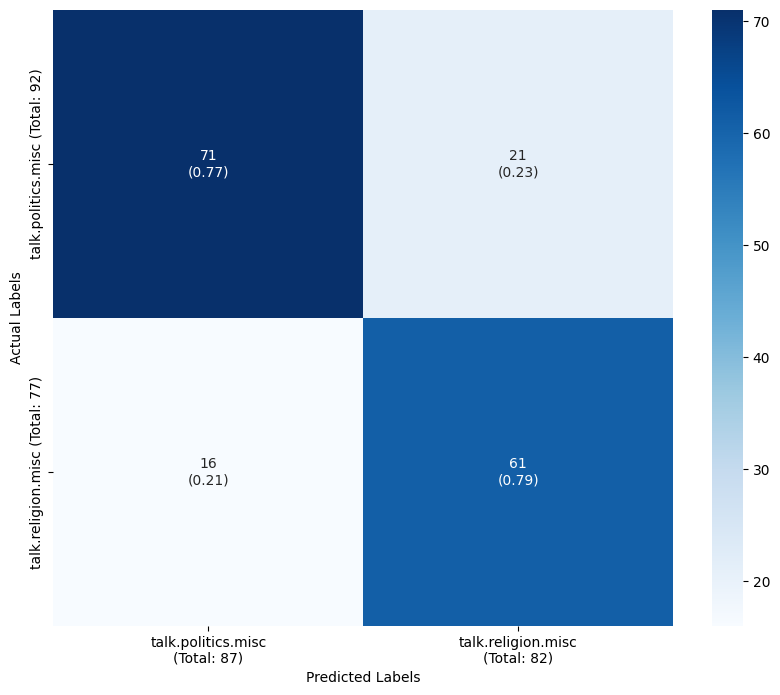

In [6]:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, labels = target_classes, target_names = target_names, digits=3))
plot_confusion_matrix(y_test, y_pred, target_classes, target_names)

Let's create a more complex pipeline with different kinds of features, but first we need some lists of related words to extract features.

In [7]:
empath_lexicons = get_empath_lexicons()

Now, let's build a pipeline that combines tf-idf weighted token features, features based on lexicons of related words and embeddings. The pipeline applies feature selection using standard scikit-learn components.

In [8]:
pipeline = Pipeline([
    ('cleaner', TextCleaner(strip_whitespace=True)),
    ('preprocessor', SpacyPreprocessor(feature_store=feature_store)),
    ('features', FeatureUnion([

        ('tokens', Pipeline([
            ('tokens_vectors',  TokensVectorizer(feature_store=feature_store, vectorizer_type = 'tfidf', lowercase=True, max_features=10000, ngram_range = (1, 2), remove_punctuation = True, remove_numbers=True, min_token_length=2)),
            ('selector', SelectKBest(score_func=chi2, k=200)),
            ], verbose=True)
        ),

		('lexicon', 
			Pipeline([
				('lexicon_vectorizer', LexiconCountVectorizer(feature_store=feature_store, lexicons=empath_lexicons)), 
                ('selector', SelectKBest(score_func=mutual_info_classif, k=20)),
				('scaler', StandardScaler(with_mean=False)),
				], verbose = True)),

        ('embeddings', Model2VecEmbedder(feature_store=feature_store)),
    ], verbose=True)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=4)),
], verbose=True)

display(pipeline)

Pipeline(steps=[('cleaner', TextCleaner(strip_whitespace=True)),
                ('preprocessor',
                 SpacyPreprocessor(feature_store=<textplumber.store.TextFeatureStore object at 0x7f9ecfa81a90>)),
                ('features',
                 FeatureUnion(transformer_list=[('tokens',
                                                 Pipeline(steps=[('tokens_vectors',
                                                                  TokensVectorizer(feature_store=<textplumber.store.TextFeatureStore object at 0x7f9ecfa81a90>,
                                                                                   l...
                                                                                                                     'mobile', ...], ...})),
                                                                 ('selector',
                                                                  SelectKBest(k=20,
                                                                              score_func=<function mutual_info_classif at 0x7f9edbdb7ba0>)),
                                                                 ('scaler',
                                                                  StandardScaler(with_mean=False))],
                                                          verbose=True)),
                                                ('embeddings',
                                                 Model2VecEmbedder(feature_store=<textplumber.store.TextFeatureStore object at 0x7f9ecfa81a90>))],
                              verbose=True)),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=4))],
         verbose=True)

Notice below - that the preprocessor step is significantly faster, as we are getting the features from the feature store. 

In [9]:
pipeline.fit(X_train, y_train)

[Pipeline] ........... (step 1 of 4) Processing cleaner, total=   0.0s
[Pipeline] ...... (step 2 of 4) Processing preprocessor, total=   0.0s
[Pipeline] .... (step 1 of 2) Processing tokens_vectors, total=   0.3s
[Pipeline] .......... (step 2 of 2) Processing selector, total=   0.0s
[FeatureUnion] ........ (step 1 of 3) Processing tokens, total=   0.3s
[Pipeline]  (step 1 of 3) Processing lexicon_vectorizer, total=  10.8s
[Pipeline] .......... (step 2 of 3) Processing selector, total=   0.3s
[Pipeline] ............ (step 3 of 3) Processing scaler, total=   0.0s
[FeatureUnion] ....... (step 2 of 3) Processing lexicon, total=  11.1s
[FeatureUnion] .... (step 3 of 3) Processing embeddings, total=   0.1s
[Pipeline] .......... (step 3 of 4) Processing features, total=  11.4s
[Pipeline] ........ (step 4 of 4) Processing classifier, total=   0.1s


Pipeline(steps=[('cleaner', TextCleaner(strip_whitespace=True)),
                ('preprocessor',
                 SpacyPreprocessor(feature_store=<textplumber.store.TextFeatureStore object at 0x7f9ecfa81a90>)),
                ('features',
                 FeatureUnion(transformer_list=[('tokens',
                                                 Pipeline(steps=[('tokens_vectors',
                                                                  TokensVectorizer(feature_store=<textplumber.store.TextFeatureStore object at 0x7f9ecfa81a90>,
                                                                                   l...
                                                                                                                     'mobile', ...], ...})),
                                                                 ('selector',
                                                                  SelectKBest(k=20,
                                                                              score_func=<function mutual_info_classif at 0x7f9edbdb7ba0>)),
                                                                 ('scaler',
                                                                  StandardScaler(with_mean=False))],
                                                          verbose=True)),
                                                ('embeddings',
                                                 Model2VecEmbedder(feature_store=<textplumber.store.TextFeatureStore object at 0x7f9ecfa81a90>))],
                              verbose=True)),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=4))],
         verbose=True)

                    precision    recall  f1-score   support

talk.politics.misc      0.838     0.902     0.869        92
talk.religion.misc      0.871     0.792     0.830        77

          accuracy                          0.852       169
         macro avg      0.855     0.847     0.850       169
      weighted avg      0.853     0.852     0.851       169



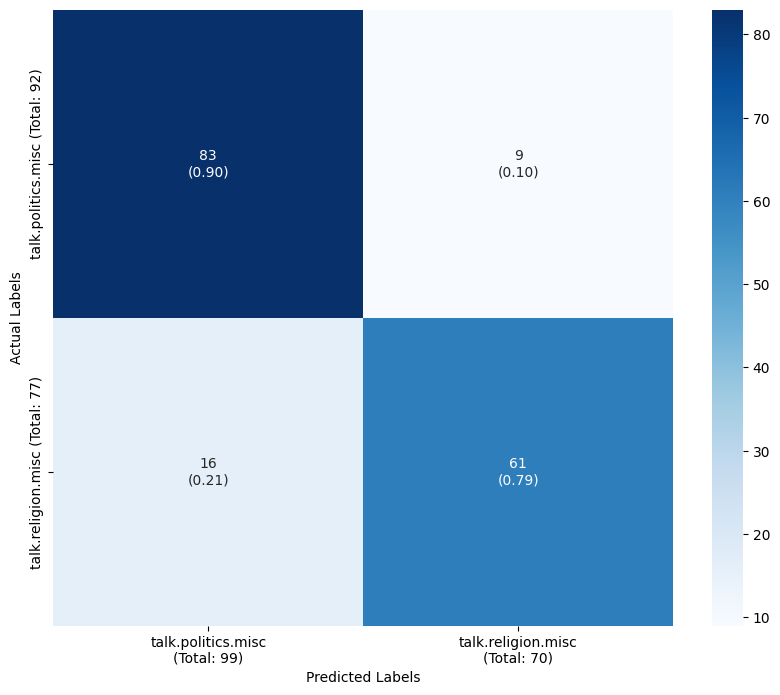

In [10]:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, labels = target_classes, target_names = target_names, digits=3))
plot_confusion_matrix(y_test, y_pred, target_classes, target_names)

The pipeline components allow you to extract a other feature types including features based on parts of speech and document-level statistics. Look at the [example notebook](example.ipynb) for a more extensive example.